# AE Anomaly Detection — Interactive Training
Train an Autoencoder on QCD (background only) and evaluate AUROC on QCD vs VBFHbb.

## 1. Setup

In [1]:
import sys
import os

# Add project root to path
PROJECT_ROOT = '/afs/cern.ch/user/d/dgenoves/Baseline_AD_Collide2v'
sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

import torch
import lightning as L
from lightning.pytorch.callbacks import ModelCheckpoint, EarlyStopping

from src.models.ae_module import AELitModule
from src.data.collide2v_datamodule import COLLIDE2VDataModule

L.seed_everything(42, workers=True)   

print(f'PyTorch: {torch.__version__}')
print(f'Lightning: {L.__version__}')
print(f'GPU available: {torch.cuda.is_available()}')


Seed set to 42


PyTorch: 2.10.0+cu128
Lightning: 2.6.1
GPU available: True


## 2. Config

In [ ]:
# --- Paths ---
DATASET_DIR  = '/eos/project/f/foundational-model-dataset/samples/production_final'
EOS_DATA_DIR = '/eos/user/d/dgenoves/Baseline_AD_Collide2v_data'
LABEL        = 'AD_QCD_VBFHbb'

paths = {
    'dataset_dir':    DATASET_DIR,
    'tmp_vec_dir':    f'{EOS_DATA_DIR}/{LABEL}/vectorized/',
    'eos_vec_dir':    f'{EOS_DATA_DIR}/{LABEL}/vectorized/',
    'tmp_preproc_dir':f'{EOS_DATA_DIR}/{LABEL}/preprocessed/',
    'eos_preproc_dir':f'{EOS_DATA_DIR}/{LABEL}/preprocessed/',
}

# --- Data ---
TRAIN_EVENTS = 500_000
VAL_EVENTS   = 20_000    # QCD only
TEST_EVENTS  = 20_000    # QCD + VBFHbb
BATCH_SIZE   = 2048

datasets_config = {
    'jets': {
        'cols': ['FullReco_JetPuppiAK4_PT','FullReco_JetPuppiAK4_Eta','FullReco_JetPuppiAK4_Phi',
                 'FullReco_JetPuppiAK4_Mass','FullReco_JetPuppiAK4_BTag',
                 'FullReco_JetPuppiAK4_NCharged','FullReco_JetPuppiAK4_NNeutrals'],
        'topk': 12, 'count': True
    },
    'electrons': {
        'cols': ['FullReco_Electron_PT','FullReco_Electron_Eta','FullReco_Electron_Phi',
                 'FullReco_Electron_Charge','FullReco_Electron_EhadOverEem',
                 'FullReco_Electron_IsolationVarRhoCorr','FullReco_Electron_D0','FullReco_Electron_DZ'],
        'topk': 8, 'count': False
    },
    'muons': {
        'cols': ['FullReco_MuonTight_PT','FullReco_MuonTight_Eta','FullReco_MuonTight_Phi',
                 'FullReco_MuonTight_Charge','FullReco_MuonTight_IsolationVarRhoCorr',
                 'FullReco_MuonTight_D0','FullReco_MuonTight_DZ'],
        'topk': 8, 'count': False
    },
    'photons': {
        'cols': ['FullReco_PhotonTight_PT','FullReco_PhotonTight_Eta','FullReco_PhotonTight_Phi',
                 'FullReco_PhotonTight_EhadOverEem','FullReco_PhotonTight_IsolationVarRhoCorr'],
        'topk': 8, 'count': False
    },
    'puppi_met': {
        'cols': ['FullReco_PUPPIMET_MET','FullReco_PUPPIMET_Phi'],
        'topk': None, 'count': False
    },
}

# --- Model ---
LATENT_DIM   = 16
HIDDEN_DIMS  = [256, 128, 64]
LR           = 1e-4
WEIGHT_DECAY = 1e-4

# --- Training ---
MAX_EPOCHS       = 100
EARLY_STOP_PAT   = 20      # patience early stopping
GRAD_CLIP_VAL    = 1.0

## 3. DataModule

In [ ]:
datamodule = COLLIDE2VDataModule(
    batch_size=BATCH_SIZE,
    train_val_test_split_per_class=[TRAIN_EVENTS, VAL_EVENTS, TEST_EVENTS],
    num_workers=27,
    pin_memory=True,
    label=LABEL,
    paths=paths,
    datasets_config=datasets_config,
    preprocess={
        'enabled': False,  # dati già preprocessati su EOS
        'feature_transforms': {},
        'feature_normalizations': {},
    },
    to_classify=['QCD_inclusive', 'VBFHbb'],
    process_to_folder={'QCD_inclusive': 'QCD_HT50toInf', 'VBFHbb': 'VBFHbb'},
    background_class='QCD_inclusive',
)

datamodule.prepare_data()
datamodule.setup('fit')
print(f'vlen (input features): {datamodule.vlen}')


🟡 Generating vectorized data in /eos/user/d/dgenoves/Baseline_AD_Collide2v_data/AD_QCD_VBFHbb/vectorized/
✓ feature_map.json saved → /eos/user/d/dgenoves/Baseline_AD_Collide2v_data/AD_QCD_VBFHbb/vectorized/
🟡 Using existing split manifest: /eos/user/d/dgenoves/Baseline_AD_Collide2v_data/AD_QCD_VBFHbb/vectorized/split_manifest.json
🟡 Processing QCD_inclusive/train (66 files)
🟡 Processing QCD_inclusive/val (3 files)
🟡 Processing QCD_inclusive/test (3 files)
🟡 Processing VBFHbb/train (58 files)
🟡 Processing VBFHbb/val (3 files)
🟡 Processing VBFHbb/test (3 files)
✅ Finished vectorizing → /eos/user/d/dgenoves/Baseline_AD_Collide2v_data/AD_QCD_VBFHbb/vectorized/
🟡 Preprocessing disabled. Performing safety checks on EOS preprocessed directory...
✅ Safety check passed: EOS preprocessed data present.
✅ Loaded preprocessed feature dimension: vlen = 316
Class QCD_inclusive had enough events (507651 events, required: 500000 events).
Class QCD_inclusive had enough events (24609 events, required: 20

## 4. Model

In [4]:
from functools import partial

model = AELitModule(
    latent_dim=LATENT_DIM,
    hidden_dims=HIDDEN_DIMS,
    lr=LR,
    weight_decay=WEIGHT_DECAY,
    optimizer=partial(torch.optim.AdamW, lr=LR, weight_decay=WEIGHT_DECAY),
    scheduler=None,
    compile=False,
)

print(model)


AELitModule(
  (train_loss): MeanMetric()
  (val_loss): MeanMetric()
  (test_loss): MeanMetric()
  (test_auroc): BinaryAUROC()
)


## 5. Trainer & Callbacks

In [5]:
callbacks = [
    EarlyStopping(monitor='val/loss', patience=EARLY_STOP_PAT, mode='min'),
    ModelCheckpoint(
        dirpath=f'{PROJECT_ROOT}/logs/notebooks/ae/',
        filename='epoch_{epoch:03d}',
        monitor='val/loss',
        mode='min',
        save_last=True,
    ),
]

trainer = L.Trainer(
    max_epochs=MAX_EPOCHS,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1,
    gradient_clip_algorithm='norm',
    gradient_clip_val=GRAD_CLIP_VAL,
    callbacks=callbacks,
    enable_model_summary=True,
)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## 6. Training

In [6]:
trainer.fit(model, datamodule=datamodule)

🟡 Generating vectorized data in /eos/user/d/dgenoves/Baseline_AD_Collide2v_data/AD_QCD_VBFHbb/vectorized/
✓ feature_map.json saved → /eos/user/d/dgenoves/Baseline_AD_Collide2v_data/AD_QCD_VBFHbb/vectorized/
🟡 Using existing split manifest: /eos/user/d/dgenoves/Baseline_AD_Collide2v_data/AD_QCD_VBFHbb/vectorized/split_manifest.json
🟡 Processing QCD_inclusive/train (66 files)
🟡 Processing QCD_inclusive/val (3 files)
🟡 Processing QCD_inclusive/test (3 files)
🟡 Processing VBFHbb/train (58 files)
🟡 Processing VBFHbb/val (3 files)
🟡 Processing VBFHbb/test (3 files)
✅ Finished vectorizing → /eos/user/d/dgenoves/Baseline_AD_Collide2v_data/AD_QCD_VBFHbb/vectorized/
🟡 Preprocessing disabled. Performing safety checks on EOS preprocessed directory...
✅ Safety check passed: EOS preprocessed data present.
✅ Loaded preprocessed feature dimension: vlen = 316


/eos/user/d/dgenoves/conda_envs/collidenv/lib/python3.11/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /afs/cern.ch/user/d/dgenoves/Baseline_AD_Collide2v/logs/notebooks/ae exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Class QCD_inclusive had enough events (507651 events, required: 500000 events).
Class QCD_inclusive had enough events (24609 events, required: 20000 events).
Class VBFHbb had enough events (25942 events, required: 20000 events).
Class QCD_inclusive had enough events (24644 events, required: 20000 events).
Class VBFHbb had enough events (26073 events, required: 20000 events).
🟡 Preprocessed data found — using from /eos/user/d/dgenoves/Baseline_AD_Collide2v_data/AD_QCD_VBFHbb/preprocessed/


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type        ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ train_loss │ MeanMetric  │      0 │ train │     0 │
│ 1 │ val_loss   │ MeanMetric  │      0 │ train │     0 │
│ 2 │ test_loss  │ MeanMetric  │      0 │ train │     0 │
│ 3 │ test_auroc │ BinaryAUROC │      0 │ train │     0 │
│ 4 │ net        │ AutoEncoder │  246 K │ train │     0 │
└───┴────────────┴─────────────┴────────┴───────┴───────┘

Trainable params: 246 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 246 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 23                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

/eos/user/d/dgenoves/conda_envs/collidenv/lib/python3.11/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/eos/user/d/dgenoves/conda_envs/collidenv/lib/python3.11/site-packages/lightning/pytorch/utilities/_pytree.py:21: 
`isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.


[Epoch 000] val/loss=0.1777

[Epoch 000] val/loss=0.0558

[Epoch 001] val/loss=0.0355

[Epoch 002] val/loss=0.0341

[Epoch 003] val/loss=0.0336

[Epoch 004] val/loss=0.0304

[Epoch 005] val/loss=0.0281

[Epoch 006] val/loss=0.0263

[Epoch 007] val/loss=0.0247

[Epoch 008] val/loss=0.0223

[Epoch 009] val/loss=0.0199

[Epoch 010] val/loss=0.0184

[Epoch 011] val/loss=0.0178

[Epoch 012] val/loss=0.0175

[Epoch 013] val/loss=0.0173

[Epoch 014] val/loss=0.0167

[Epoch 015] val/loss=0.0160

[Epoch 016] val/loss=0.0156

[Epoch 017] val/loss=0.0153

[Epoch 018] val/loss=0.0152

[Epoch 019] val/loss=0.0151

[Epoch 020] val/loss=0.0150

[Epoch 021] val/loss=0.0149

[Epoch 022] val/loss=0.0146

[Epoch 023] val/loss=0.0144

[Epoch 024] val/loss=0.0141

[Epoch 025] val/loss=0.0137

[Epoch 026] val/loss=0.0132

[Epoch 027] val/loss=0.0128

[Epoch 028] val/loss=0.0126

[Epoch 029] val/loss=0.0125

[Epoch 030] val/loss=0.0123

[Epoch 031] val/loss=0.0122

[Epoch 032] val/loss=0.0122

[Epoch 033] v

`Trainer.fit` stopped: `max_epochs=100` reached.



[Epoch 099] val/loss=0.0098


## 7. Test (AUROC)

In [9]:
datamodule.setup('test')
results = trainer.test(ckpt_path='best', datamodule=datamodule, weights_only=False)
print(results)

Class QCD_inclusive had enough events (507651 events, required: 500000 events).
Class QCD_inclusive had enough events (24609 events, required: 20000 events).
Class VBFHbb had enough events (25942 events, required: 20000 events).
Class QCD_inclusive had enough events (24644 events, required: 20000 events).
Class VBFHbb had enough events (26073 events, required: 20000 events).
🟡 Preprocessed data found — using from /eos/user/d/dgenoves/Baseline_AD_Collide2v_data/AD_QCD_VBFHbb/preprocessed/
🟡 Generating vectorized data in /eos/user/d/dgenoves/Baseline_AD_Collide2v_data/AD_QCD_VBFHbb/vectorized/
✓ feature_map.json saved → /eos/user/d/dgenoves/Baseline_AD_Collide2v_data/AD_QCD_VBFHbb/vectorized/
🟡 Using existing split manifest: /eos/user/d/dgenoves/Baseline_AD_Collide2v_data/AD_QCD_VBFHbb/vectorized/split_manifest.json
🟡 Processing QCD_inclusive/train (66 files)
🟡 Processing QCD_inclusive/val (3 files)
🟡 Processing QCD_inclusive/test (3 files)
🟡 Processing VBFHbb/train (58 files)


Restoring states from the checkpoint path at /afs/cern.ch/user/d/dgenoves/Baseline_AD_Collide2v/logs/notebooks/ae/epoch_epoch=098.ckpt


🟡 Processing VBFHbb/val (3 files)
🟡 Processing VBFHbb/test (3 files)
✅ Finished vectorizing → /eos/user/d/dgenoves/Baseline_AD_Collide2v_data/AD_QCD_VBFHbb/vectorized/
🟡 Preprocessing disabled. Performing safety checks on EOS preprocessed directory...
✅ Safety check passed: EOS preprocessed data present.
✅ Loaded preprocessed feature dimension: vlen = 316
Class QCD_inclusive had enough events (507651 events, required: 500000 events).
Class QCD_inclusive had enough events (24609 events, required: 20000 events).
Class VBFHbb had enough events (25942 events, required: 20000 events).
Class QCD_inclusive had enough events (24644 events, required: 20000 events).
Class VBFHbb had enough events (26073 events, required: 20000 events).
🟡 Preprocessed data found — using from /eos/user/d/dgenoves/Baseline_AD_Collide2v_data/AD_QCD_VBFHbb/preprocessed/


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loaded model weights from the checkpoint at /afs/cern.ch/user/d/dgenoves/Baseline_AD_Collide2v/logs/notebooks/ae/epoch_epoch=098.ckpt


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        test/auroc         │     0.952680766582489     │
│         test/loss         │    0.0234268419444561     │
└───────────────────────────┴───────────────────────────┘

[{'test/loss': 0.0234268419444561, 'test/auroc': 0.952680766582489}]


## 8. Inspect reconstruction error distribution

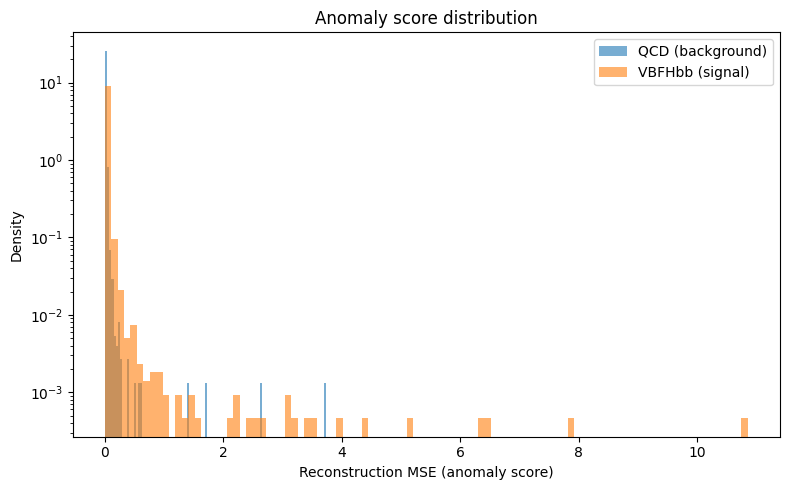

In [10]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

model.eval()
model.to('cuda' if torch.cuda.is_available() else 'cpu')
device = next(model.parameters()).device

scores, labels = [], []
with torch.no_grad():
    for x, y in datamodule.test_dataloader():
        x = x.to(device)
        x_hat = model(x)
        mse = F.mse_loss(x_hat, x, reduction='none').mean(dim=-1)
        scores.append(mse.cpu())
        labels.append(y)

scores = torch.cat(scores).numpy()
labels = torch.cat(labels).numpy()

qcd_scores = scores[labels == 0]
sig_scores = scores[labels == 1]

plt.figure(figsize=(8, 5))
plt.hist(qcd_scores, bins=100, alpha=0.6, label='QCD (background)', density=True)
plt.hist(sig_scores, bins=100, alpha=0.6, label='VBFHbb (signal)', density=True)
plt.xlabel('Reconstruction MSE (anomaly score)')
plt.ylabel('Density')
plt.legend()
plt.yscale('log')
plt.title('Anomaly score distribution')
plt.tight_layout()
plt.show()